## Khảo sát Big-Vul

Dataset này có gì, và hình dạng của nó ra sao.

Kết luận quan trọng nhất nằm ở cuối: 217,007 dòng thực chất chỉ là ~4,000 mẫu
độc lập, vì Big-Vul thu thập dữ liệu theo **commit vá lỗi**, không theo hàm.
Con số đó quyết định cách chia train/test ở Phase 2.


In [1]:
from datasets import load_dataset
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
dsd = load_dataset("benjis/bigvul")

Load_dataset trả về một DatasetDict, nó chứa nhiều tập con (split) train, validation, test.

In [3]:
sns.set_theme(style="whitegrid")
df = pd.concat(
    [dsd[split].to_pandas() for split in dsd],
    ignore_index=True
)
df.head(10)

,CVE ID,CVE Page,CWE ID,codeLink,commit_id,commit_message,func_after,func_before,lang,project,vul
0,CVE-2017-7586,https://www.cvedetails.com/cve/CVE-2017-7586/,CWE-119,https://github.com/erikd/libsndfile/commit/708...,708e996c87c5fae77b104ccfeb8f6db784c32074,src/ : Move to a variable length header buffer...,"psf_get_date_str (char *str, int maxlen)\n{\tt...","psf_get_date_str (char *str, int maxlen)\n{\tt...",C,libsndfile,0
1,CVE-2018-18352,https://www.cvedetails.com/cve/CVE-2018-18352/,CWE-732,https://github.com/chromium/chromium/commit/a9...,a9cbaa7a40e2b2723cfc2f266c42f4980038a949,"Simplify ""WouldTaintOrigin"" concept in media/b...",void MultibufferDataSource::CreateResourceLoad...,void MultibufferDataSource::CreateResourceLoad...,C,Chrome,0
2,CVE-2010-1166,https://www.cvedetails.com/cve/CVE-2010-1166/,CWE-189,https://cgit.freedesktop.org/xorg/xserver/comm...,d2f813f7db157fc83abc4b3726821c36ee7e40b1,NaN,"fbStore_a2r2g2b2 (FbBits *bits, const CARD32 *...","fbStore_a2r2g2b2 (FbBits *bits, const CARD32 *...",C,xserver,0
3,NaN,NaN,NaN,https://github.com/chromium/chromium/commit/61...,610f904d8215075c4681be4eb413f4348860bf9f,Retrieve per host storage usage from QuotaMana...,void UsageTracker::DidGetClientGlobalUsage(Sto...,void UsageTracker::DidGetClientGlobalUsage(Sto...,C,Chrome,0
4,NaN,NaN,NaN,https://github.com/chromium/chromium/commit/95...,957973753ec4159003ff7930d946b7e89c7e09f3,Make NotifyHeadersComplete the last call in th...,void BlobURLRequestJob::DidRead(int result) {\...,void BlobURLRequestJob::DidRead(int result) {\...,C,Chrome,0
5,CVE-2017-11462,https://www.cvedetails.com/cve/CVE-2017-11462/,CWE-415,https://github.com/krb5/krb5/commit/56f7b1bc95...,56f7b1bc95a2a3eeb420e069e7655fb181ade5cf,Preserve GSS context on init/accept failure\n\...,"gss_get_mic (minor_status,\n\t context_han...","gss_get_mic (minor_status,\n\t context_han...",C,krb5,1
6,CVE-2013-0910,https://www.cvedetails.com/cve/CVE-2013-0910/,CWE-287,https://github.com/chromium/chromium/commit/ac...,ac8bd041b81e46e4e4fcd5021aaa5499703952e6,Follow-on fixes and naming changes for https:/...,void PluginServiceImpl::RegisterFilePathWatche...,void PluginServiceImpl::RegisterFilePathWatche...,C,Chrome,0
7,CVE-2015-5195,https://www.cvedetails.com/cve/CVE-2015-5195/,CWE-20,https://github.com/ntp-project/ntp/commit/52e9...,52e977d79a0c4ace997e5c74af429844da2f27be,[Bug 1773] openssl not detected during ./confi...,"record_loop_stats(\n\tdouble\toffset,\t\t/* of...","record_loop_stats(\n\tdouble\toffset,\t\t/* of...",C,ntp,0
8,CVE-2017-18222,https://www.cvedetails.com/cve/CVE-2017-18222/,CWE-119,https://github.com/torvalds/linux/commit/412b6...,412b65d15a7f8a93794653968308fc100f2aa87c,net: hns: fix ethtool_get_strings overflow in ...,static void hns_xgmac_exc_irq_en(struct mac_dr...,static void hns_xgmac_exc_irq_en(struct mac_dr...,C,linux,0
9,CVE-2018-6077,https://www.cvedetails.com/cve/CVE-2018-6077/,CWE-200,https://github.com/chromium/chromium/commit/6e...,6ed26f014f76f10e76e80636027a2db9dcbe1664,[PE] Distinguish between tainting due to canva...,void BaseRenderingContext2D::clip(Path2D* dom_...,void BaseRenderingContext2D::clip(Path2D* dom_...,C,Chrome,0


In [4]:
print("Số dòng: ", df.shape[0])
print("Số cột: ", df.shape[1])

Số dòng:  217007
Số cột:  11


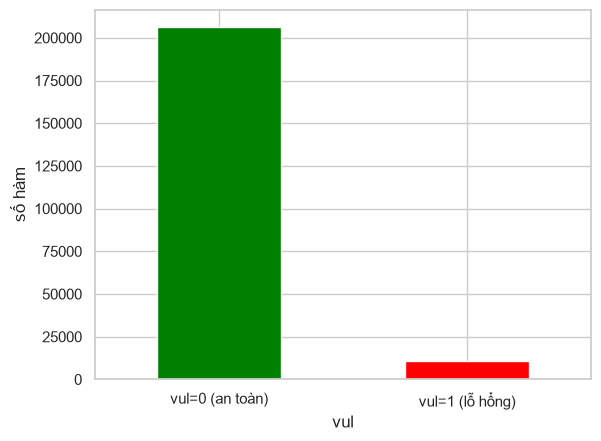

vul=0 (an toàn)    : 206,112  (94.98%)
vul=1 (có lỗ hổng) : 10,895  (5.02%)
Tỉ số              : 18.9 : 1


In [5]:
vc = df["vul"].value_counts().sort_index()
n_safe, n_vul = int(vc[0]), int(vc[1])

vc.plot(kind="bar", color=["green", "red"])
plt.xticks([0, 1], ["vul=0 (an toàn)", "vul=1 (lỗ hổng)"], rotation=0)
plt.ylabel("số hàm")
plt.show()

print(f"vul=0 (an toàn)    : {n_safe:,}  ({n_safe/len(df):.2%})")
print(f"vul=1 (có lỗ hổng) : {n_vul:,}  ({n_vul/len(df):.2%})")
print(f"Tỉ số              : {n_safe/n_vul:.1f} : 1")

In [6]:
#Lúc đầu thì bao gồm C, CPP, C++, chuyển về còn C, C++
LANG_MAP = {"C": "C", "CPP": "C++", "C++": "C++"}
df["lang"] = df["lang"].map(LANG_MAP)

print(f"Giá trị lạ sau khi map (NaN): {df['lang'].isna().sum()}")
df = df[df["lang"].isin(["C", "C++"])]     

df["lang"].value_counts()


Giá trị lạ sau khi map (NaN): 0


lang
C      213919
C++      3088
Name: count, dtype: int64

   CWE-119    2,139  (19.6%)
   CWE-20     1,136  (10.4%)
   CWE-399      742  ( 6.8%)
   CWE-125      630  ( 5.8%)
   CWE-200      508  ( 4.7%)
   CWE-264      493  ( 4.5%)
   CWE-189      341  ( 3.1%)
   CWE-416      323  ( 3.0%)
   CWE-190      311  ( 2.9%)
   CWE-362      266  ( 2.4%)


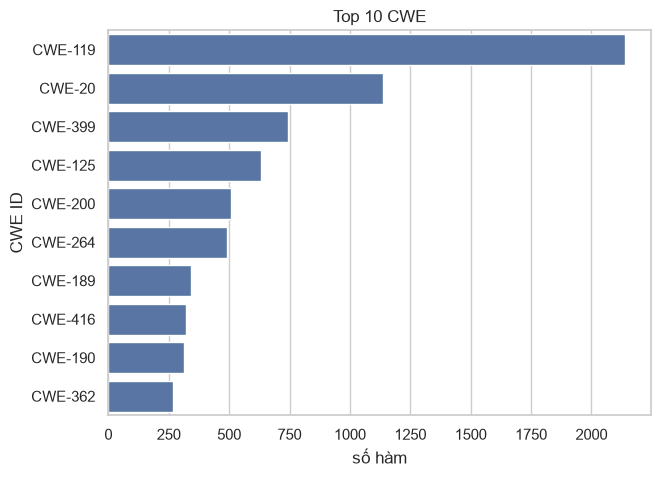

In [7]:
vul_only = df[df["vul"] == 1]
top_cwe = vul_only["CWE ID"].value_counts().head(10)
for cwe, n in top_cwe.items():
    print(f"   {str(cwe):10s} {n:>5,}  ({n/len(vul_only):5.1%})")

fig, ax = plt.subplots(figsize=(7, 5))
sns.barplot(x=top_cwe.values, y=top_cwe.index, ax=ax)
ax.set_xlabel("số hàm")
ax.set_title("Top 10 CWE")
plt.show()

Độ dài func_before (ký tự):
count    217,007
mean         899
std        2,473
min           14
25%          193
50%          393
75%          868
max      240,969
Name: func_before, dtype: str


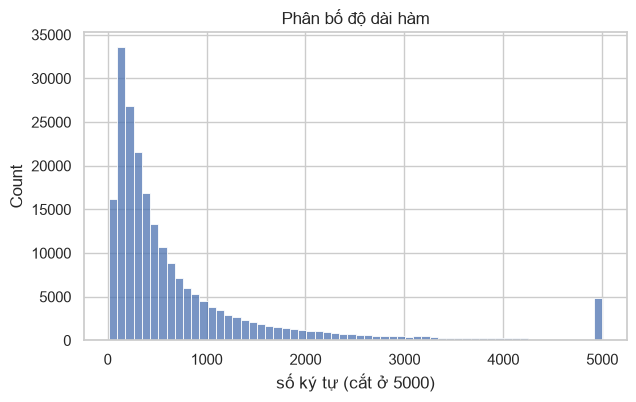


Hàm dài hơn 5000 ký tự: 4,716 (2.2%)


In [8]:
lens = df["func_before"].str.len()

print("Độ dài func_before (ký tự):")
print(lens.describe().apply(lambda x: f"{x:,.0f}"))

fig, ax = plt.subplots(figsize=(7, 4))
# clip để vài hàm cực dài không kéo giãn trục x làm mất hình dạng phần thân
sns.histplot(lens.clip(upper=5000), bins=60, ax=ax)
ax.set_xlabel("số ký tự (cắt ở 5000)")
ax.set_title("Phân bố độ dài hàm")
plt.show()

print(f"\nHàm dài hơn 5000 ký tự: {(lens > 5000).sum():,} ({(lens > 5000).mean():.1%})")

In [9]:
n_rows = len(df)
n_commits = df["commit_id"].nunique()
per_commit = df.groupby("commit_id").size()

print("=" * 50)
print(f"Tổng số dòng          : {n_rows:,}")
print(f"Số commit riêng biệt  : {n_commits:,}")
print("=" * 50)
print("Hàm / commit:")
print(f"   trung vị   : {per_commit.median():>8,.0f}")
print(f"   trung bình : {per_commit.mean():>8,.1f}")
print(f"   lớn nhất   : {per_commit.max():>8,}")
print(f"   p95        : {per_commit.quantile(0.95):>8,.0f}")


Tổng số dòng          : 217,007
Số commit riêng biệt  : 4,019
Hàm / commit:
   trung vị   :       24
   trung bình :     54.0
   lớn nhất   :    1,692
   p95        :      189


In [10]:
print("Nếu chia NGẪU NHIÊN theo DÒNG, test = 20%:\n")
print("Xác suất CẢ commit rơi trọn vào một phía:")
for k in [1, 5, 10, 24, 50]:
    print(f"   commit có {k:2d} hàm  ->  {0.2 ** k:.2e}")

print(f"\nTrung vị thật của dataset này: {per_commit.median():.0f} hàm/commit")
print("=> gần như MỌI commit đều bị xé đôi giữa train và test.")
print(f"=> {n_rows:,} dòng thực chất chỉ là {n_commits:,} mẫu độc lập "
      f"(phóng đại {n_rows/n_commits:.0f}x)")


Nếu chia NGẪU NHIÊN theo DÒNG, test = 20%:

Xác suất CẢ commit rơi trọn vào một phía:
   commit có  1 hàm  ->  2.00e-01
   commit có  5 hàm  ->  3.20e-04
   commit có 10 hàm  ->  1.02e-07
   commit có 24 hàm  ->  1.68e-17
   commit có 50 hàm  ->  1.13e-35

Trung vị thật của dataset này: 24 hàm/commit
=> gần như MỌI commit đều bị xé đôi giữa train và test.
=> 217,007 dòng thực chất chỉ là 4,019 mẫu độc lập (phóng đại 54x)
